In [29]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit
star_table = Table.read('Planet_Lightcurve.fits')
print(star_table)

    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


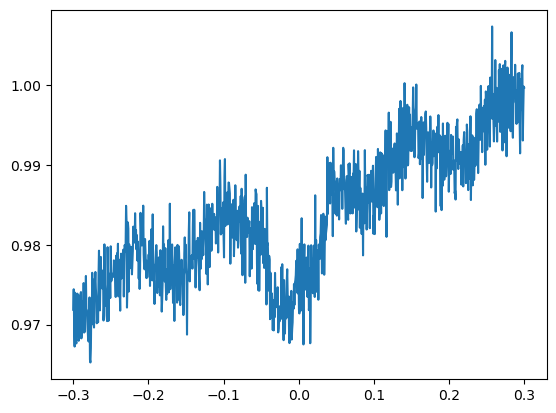

In [35]:
x1 = star_table["time [days]"]
y1 = star_table["flux"]
plt.plot(x1,y1)

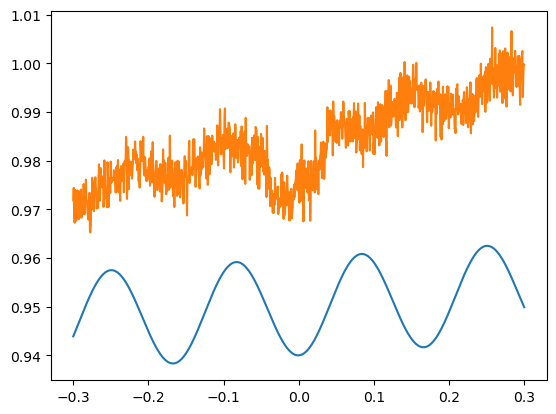

In [96]:
def model_line(x1, a, b, c, d, e):
    return a*x1 + b*np.cos(c*np.pi*(x1-d))+e
model_test = model_line(x1, a=.01,b=-.01,c=12,d=1,e=.95)
plt.plot(x1, model_test)
plt.plot(x1,y1)

(array([ 4.10310035e-02, -2.32928202e-03,  1.12589648e+01,  1.07421461e+00,
        9.83516746e-01]), array([[ 7.10293683e-07, -2.09411635e-09, -1.73230470e-05,
         1.79604471e-06,  1.07683815e-09],
       [-2.09411635e-09,  4.15480302e-08, -2.02150335e-06,
         1.86606541e-07,  3.58019034e-09],
       [-1.73230470e-05, -2.02150335e-06,  2.87004129e-02,
        -2.75791489e-03, -1.78407630e-06],
       [ 1.79604471e-06,  1.86606541e-07, -2.75791489e-03,
         2.71390988e-04,  1.84271038e-07],
       [ 1.07683815e-09,  3.58019034e-09, -1.78407630e-06,
         1.84271038e-07,  2.13760782e-08]]))


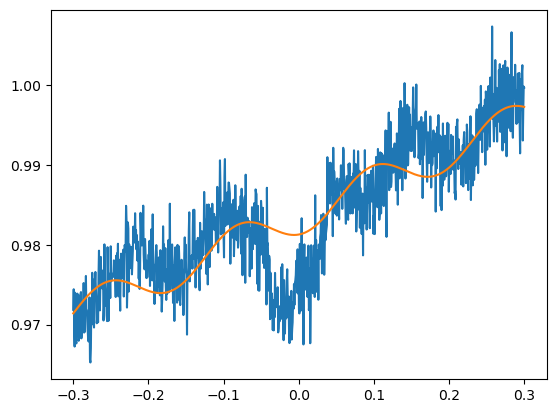

In [88]:
params_cov = curve_fit(model_line, x1, y1, sigma = 100, p0 = [1,1,12,1,1])
print(params_cov)
model_guess = model_line(x1,4.10310035e-02, -2.32928202e-03,  1.12589648e+01,  1.07421461e+00,
        9.83516746e-01)
plt.plot(x1,y1)
plt.plot(x1,model_guess)

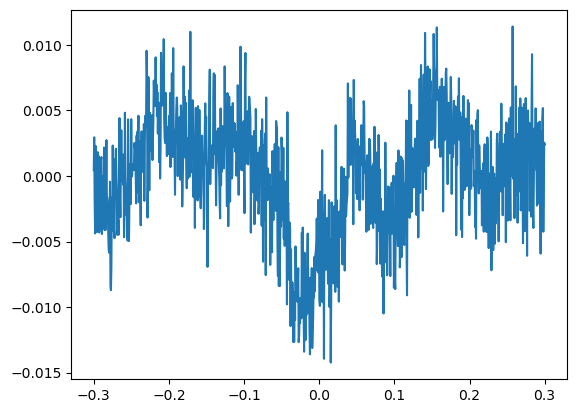

In [89]:
plt.plot(x1, y1 - model_guess)